# ALADIN workflow
This Notebook follow the step-by-step workflow for HW-SW co-design with the proposed framework.

### Imports

In [1]:
import os
import json
import importlib
import numpy as np
import pandas as pd
from importlib import import_module
from pathlib import Path

p = Path(__file__).resolve() if "__file__" in globals() else Path.cwd()

while not (p / "ALADIN").exists():   # or any marker file
    if p.parent == p:
        raise RuntimeError("Project root not found")
    p = p.parent
os.chdir(os.path.join(p, "ALADIN"))
print("CWD set to project root:", p)

MODEL_DIR = "./models"

MODELS = [
    "vgg",
    "resnet",
    "mobilenet_v1",
    "shufflenet",
    "efficientnet"
]

target_model = "shufflenet_case 3.onnx"
target_platform = 0


CWD set to project root: /workspaces


## 1. Implementation-Aware model

In [2]:
# import onnx
# from qonnx.core.modelwrapper import ModelWrapper
# from qonnx.transformation.infer_shapes import InferShapes
# from dory.Frontend_frameworks.QONNX.transformations.aladin_trace_model import ImplementationAwareTrace

# for model_name in MODELS:
#     for idx in range(1,4):
#         target_model = f"{model_name}_case {idx}.onnx"
#         model_path = os.path.join(MODEL_DIR, target_model)
#         mw = ModelWrapper(onnx.load(model_path))
#         mw = mw.transform(InferShapes()) 
#         mw.transform(ImplementationAwareTrace(
#             output_path="./output", 
#             file_name=f"STEP1_{target_model.split('.')[0]}",
#             verbose=True
#         ))

In [3]:
import onnx
from qonnx.core.modelwrapper import ModelWrapper

model_path = os.path.join(MODEL_DIR, target_model)
mw = ModelWrapper(onnx.load(model_path))

In [4]:
from qonnx.transformation.infer_shapes import InferShapes
from dory.Frontend_frameworks.QONNX.transformations.aladin_trace_model import ImplementationAwareTrace

mw = mw.transform(InferShapes()) 
mw.transform(ImplementationAwareTrace(
    output_path="./output", 
    file_name=f"STEP1_{target_model.split('.')[0]}",
    verbose=True
))

## 2. Code Generation with Dory
TODO: multi-LUT implementation

In [5]:
FRONTEND = "QONNX"                  # "NEMO", "Quantlab", "QONNX"
HARDWARE = "PULP.PULP_gvsoc"        # "PULP.GAP8", "PULP.GAP8_L2", "PULP.PULP_gvsoc", "PULP.GAP9", "PULP.GAP9_NE16"
VERBOSE = "None"    # "None", "Perf_final", "Check_all+Perf_final", "Last+Perf_final"
ISA = "mixed-sw"                    # "auto", "8bit", "mixed-hw", "mixed-sw"

# default config files
dory_config = {
	"BNRelu_bits": 32,
	"code reserved space": 150000,
    "input_bits": 8,
    "input_signed": False
}

In [6]:
meta_platforms = [
    {
        "num_cores": 8,
        "L1_capacity": 64000,
        "L2_capacity": 512000,
    },
    {
        "num_cores": 4,
        "L1_capacity": 64000,
        "L2_capacity": 320000,
    },
    {
        "num_cores": 2,
        "L1_capacity": 64000,
        "L2_capacity": 256000,
    }
]

In [7]:
onnx_manager = import_module(f"dory.Frontend_frameworks.{FRONTEND}.Parser")
onnx_to_dory = onnx_manager.onnx_manager

graph = onnx_to_dory(
    model_path, 
    dory_config, 
    delta=16
).full_graph_parsing()


###################################
## DORY GENERAL PARSING OF QONNX ##
## FINAL RAPRESENTATION: DORY IR ##
###################################
QONNX conversion complete!
Validation...
Creating Original_graph.onnx in logs/Frontend/onnx_files/
Creating Original_graph.json in logs/Frontend/json_files/
onnx_to_dory net prefix: 

##################################
## DORY GENERAL PARSING OF ONNX ##
## FINAL RAPRESENTATION:DORY IR ##
##################################

Parsing ONNX Graph to create DORY graph.
Creating 00_DORY_raw_graph.json in logs/Frontend/json_files/
Creating 00_DORY_raw_graph.onnx in logs/Frontend/onnx_files/

Embedding constant nodes inside nodes to which the tensors belong.
Creating 01_DORY_graph_constants_removed.json in logs/Frontend/json_files/
Creating 01_DORY_graph_constants_removed.onnx in logs/Frontend/onnx_files/

Quantlab Frontend: Matching patterns from generated ONNX to DORY.

Quantlab Frontend: Updating Add nodes with constants, adding 'conv1d' flags and e

In [8]:
from copy import deepcopy

PLATFORM = meta_platforms[target_platform]

NUM_CORES, L1_capacity, L2_capacity = PLATFORM.values()

onnx_manager = import_module(f'dory.Hardware_targets.{HARDWARE}.HW_Parser')
dory_to_dory_hw = onnx_manager.onnx_manager
graph_tmp = deepcopy(graph)
hw_graph = dory_to_dory_hw(
    graph_tmp,
    n_inputs=1,
    verify_checksum=False,
    L1_capacity=L1_capacity,
    L2_capacity=L2_capacity,
    config_file=dory_config,
    num_cores=NUM_CORES
).full_graph_parsing()

onnx_manager_PULP: Key 'double_buffering' not found in HW_description.json - setting to 2
#####################################################
## DORY GENERAL PARSING FROM DORY IR TO DORY HW IR ##
## FINAL RAPRESENTATION: DORY HW IR                ##
#####################################################
Creating 00_DORY_HW_input_graph.json in logs/HW_related/json_files/
Creating 00_DORY_HW_input_graph.onnx in logs/HW_related/onnx_files/

Backend: Matching patterns from generated DORY ONNX to HW Nodes.
Creating 01_DORY_HW_graph_raw.json in logs/HW_related/json_files/
Creating 01_DORY_HW_graph_raw.onnx in logs/HW_related/onnx_files/

DORY generic Frontend. Updating branches pointers.
Creating 02_DORY_HW_graph_fixed_branches.json in logs/HW_related/json_files/
Creating 02_DORY_HW_graph_fixed_branches.onnx in logs/HW_related/onnx_files/

Updating dimensions of vectors inside the graph, if they do not match among nodes
Creating 03_DORY_HW_graph_fixed_dimensions.json in logs/HW_related/json

In [9]:
onnx_manager = import_module(f'dory.Hardware_targets.{HARDWARE}.C_Parser')
dory_hw_to_c = onnx_manager.C_Parser
dory_hw_to_c(
    hw_graph, 
    dory_config,
    verbose_level=VERBOSE,
    perf_layer="Yes", 
    precision_library=ISA,
    app_directory="./application", 
    model_dir="./models",
    n_inputs=1,
    L1_capacity=L1_capacity,
    L2_capacity=L2_capacity
).full_graph_parsing()

C_Parser_PULP: Key 'double_buffering' not found in HW_description.json - setting to 2
#####################################################
## DORY GENERAL PARSING FROM DORY HW IR TO C FILES ##
## FINAL RAPRESENTATION: COMPILABLE C PROJECT      ##
#####################################################

Generating the .c file of the network.

Generating the Makefile.
Makefile template writer: key 'single_core_dma' not found in HW description, using multi-core transfers!
Makefile template writer: key 'single_core_dma' not found in HW description, using multi-core transfers!

Mapping the layers files to their templates and copying the kernels associated.

Copying Utils.

Generating .hex weight files.
Saved ./application/hex/ReluConvolution0_weights.hex: 448 values, 1792 source bytes
Saved ./application/hex/ReluConvolution1_weights.hex: 160 values, 640 source bytes
Saved ./application/hex/ReluConvolution2_weights.hex: 408 values, 1632 source bytes
Saved ./application/hex/ReluConvolution3_we

## 3. Platform-Aware modele
TODO: Graham's bound

In [10]:
import dory.Frontend_frameworks.QONNX.transformations.aladin_latency_model as alm
from dataclasses import replace


hardware_name = str(HARDWARE).split(".")[-1]

hw_spec_path = (
    Path("./dory")
    / "Hardware_targets"
    / "PULP"
    / hardware_name
    / "HW_description.json"
)

with hw_spec_path.open("r") as handle:
    raw_hw_spec = json.load(handle)

raw_hw_spec["memory"]["L1"]["dimension"] = int(
    L1_capacity
)
raw_hw_spec["memory"]["L2"]["dimension"] = int(
    L2_capacity
)

hw_spec = alm.prepare_pulp_hw_spec(
    raw_hw_spec
)


estimator = alm.LatencyEstimator.simple(
    hw_spec,
    num_cores=int(NUM_CORES),
    generated_code_dir=(
        "./application/DORY_network/src"
    ),
)


estimator.tiling = alm.TilingModelConfig(
    enabled=True,
    level_name="L1",
    compute_mode="shape_aware",

    edge_tile_safety_factor=1.03,
    unknown_geometry_compute_factor=1.10,
    unknown_geometry_dma_redundancy_factor=1.10,
    max_dma_redundancy_factor=4.0,

    use_generated_tile_count_first=True,
)

estimator.pessimism = alm.PessimismConfig(
    kernel_safety_factor=2.0,
    depthwise_kernel_safety_factor=2.0,
    grouped_kernel_safety_factor=1.0,
    pooling_kernel_safety_factor=3.2,
    pooling_memory_pressure_factor=1.0,
    linear_kernel_safety_factor=2.8,
    add_kernel_safety_factor=1.8,
    add_memory_pressure_factor=1.0,
    dma_safety_factor=1.0,
    bank_correlation_inflation=0.0,
    bank_spread_haircut=0.0,
    conflict_excess_factor=1.0,
    layer_fixed_overhead_cycles=100,
    kernel_launch_cycles=20,
    team_barrier_cycles=25,
    dma_allocate_cycles=8,
    dma_free_cycles=8,
)

estimator.auto_spec = replace(
    estimator.auto_spec,

    weight_correlation=0.30,
    bias_correlation=0.20,
    input_correlation=0.10,
    im2col_correlation=0.05,
    output_correlation=0.05,

    depthwise_weight_correlation=0.05,
    depthwise_input_correlation=0.05,
    depthwise_im2col_correlation=0.02,
    depthwise_output_correlation=0.02,

    pooling_input_correlation=0.10,
    pooling_output_correlation=0.05,

    linear_input_correlation=0.30,
    linear_weight_correlation=0.15,
    linear_bias_correlation=0.15,
    linear_output_correlation=0.05,

    add_input1_correlation=0.0,
    add_input2_correlation=0.0,
    add_output_correlation=0.0,
)

estimator.kernel_cost = replace(
    estimator.kernel_cost,

    add_input_load_cycles_per_value=0.50,
    add_input_requant_cycles_per_operand=1.50,
    add_clip_cycles_per_value=0.50,
    add_sum_cycles_per_value=0.75,
    add_output_requant_cycles_per_value=1.50,
    add_output_store_cycles_per_value=0.50,
    add_group4_overhead_cycles=3.0,
)

results = estimator.process(hw_graph)

df = pd.DataFrame([
    {"name": r["name"], "latency": r["pessimistic_cycles"]}
    for r in results
])
predicted_latency_path = f"./output/STEP2_{target_model.split('.')[0]}_platform {target_platform+1}_latency.csv"
df.to_csv(predicted_latency_path, index=False)

## 4. GVSoC simulation
*NOTE*: this portion of the notebooks run only inside the container.

In [11]:
import subprocess


cmd = f"""
    source .devcontainer/pulp_sdk.sh
    export PATH=/dory_env/bin:$PATH
    make -C ./application clean all run platform=gvsoc CORE={NUM_CORES}
"""
try:
    proc = subprocess.run(
        ["bash", "-c", cmd],
        check=True,
        capture_output=True,
        text=True,
        timeout=360,
    )
    
except subprocess.CalledProcessError as e:
    raise RuntimeError(
        f"Build or run failed (exit {e.returncode}):\n"
        f"STDOUT:\n{e.stdout}\n"
        f"STDERR:\n{e.stderr}"
    )
except subprocess.TimeoutExpired as e:
    raise TimeoutError(
        f"Test timed out after 720s.\n"
        f"Partial STDOUT:\n{e.stdout}\n"
        f"STDERR:\n{e.stderr}"
    )
    
proc.stdout

"make: Entering directory '/workspaces/ALADIN/application'\nRM  /workspaces/ALADIN/application/BUILD/PULP/GCC_RISCV/\nCC  src/ReluConvolution31.c\nCC  src/pulp_nn_conv_u8_u4_i8.c\nCC  src/ReluConvolution3.c\nCC  src/pulp_nn_depthwise_u8_u4_i4.c\nCC  src/ReluConvolution35.c\nCC  src/pulp_nn_conv_u4_i4_i4.c\nCC  src/pulp_nn_matmul_u8_u4_i8.c\nCC  src/pulp_nn_conv_u4_i4_i8.c\nCC  src/pulp_nn_conv_lut_u4_i4_i4.c\nCC  src/dory_dma.c\nCC  src/ReluConvolution1.c\nCC  src/ReluConvolution41.c\nCC  src/ReluConvolution29.c\nCC  src/ReluConvolution34.c\nCC  src/Addition32.c\nCC  src/pulp_nn_linear_i8_i8_i8.c\nCC  src/ReluConvolution5.c\nCC  src/ReluConvolution12.c\nCC  src/pulp_nn_matmul_i8_i8_i8.c\nCC  src/pulp_nn_matmul_lut_i8_u4_i4.c\nCC  src/ReluConvolution9.c\nCC  src/pulp_nn_matmul_u8_i4_i4.c\nCC  src/ReluConvolution2.c\nCC  src/ReluConvolution37.c\nCC  src/Addition10.c\nCC  src/ReluConvolution45.c\nCC  src/Addition14.c\nCC  src/ReluConvolution36.c\nCC  src/pulp_nn_matmul_u8_i4_i8.c\nCC  src

Store results:

In [12]:
import csv

csv_path = os.path.join(
    "./output",
    f"STEP3_paltform {target_platform+1}_{target_model.split('.')[0]}.csv"
)
os.makedirs(os.path.dirname(csv_path), exist_ok=True)

In [13]:
with open("./logs/HW_related/json_files/06_DORY_HW_tiled_graph.json", "r") as f:
    layers_tiling_info = json.load(f)["graph"]

In [14]:

def sum_componenets(tile: dict) -> int:
    return sum((
        tile["weight_memory"],
        tile["bias_memory"],
        tile["constants_memory"],
        tile["input_activation_memory"],
        tile["output_activation_memory"],
        tile.get("lut_memory", 0),
    ))
                        


with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "layer_name", 
        "MACs", 
        "num_cycles", 
        "MAC_per_cycle", 
        "num_cores", 
        "L1_mem", 
        "L2_mem", 
        "L1_tiling", 
        "L2_tiling"
    ])
    idx = 0
    for line in proc.stdout.splitlines():
        if not line.startswith("PERF_LOG"):
            continue
            
        info = line.strip().split(",")
        if len(info) != 6:
            continue
        
        _, layer_name, macs, cycles, perf, cores = info
        tiling_info = layers_tiling_info[idx]["Tiling_parameters"]
        idx += 1
        writer.writerow([
            layer_name,
            int(macs),
            int(cycles),
            float(perf),
            int(cores),
            L1_capacity,
            L2_capacity,
            sum_componenets(tiling_info["L1"]),
            sum_componenets(tiling_info["L2"])
        ])

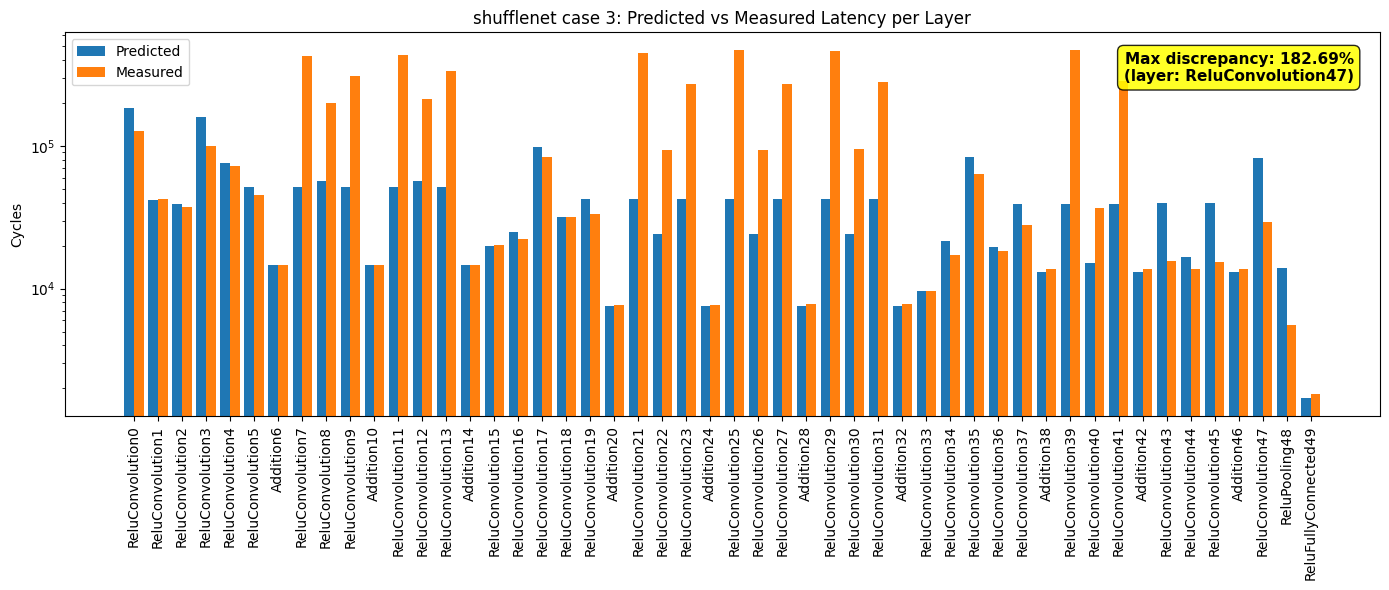

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

predicted = pd.read_csv(predicted_latency_path)  # columns: name, latency
measured  = pd.read_csv(csv_path)                 # columns: layer_name, MACs, num_cycles, ...

predicted = predicted.rename(columns={"latency": "predicted_latency"})
measured  = measured.rename(columns={"layer_name": "name", "num_cycles": "measured_latency"})

comparison = predicted.merge(measured[["name", "measured_latency"]], on="name", how="inner")

# Relative error ratio (unitless)
comparison["rel_error_ratio"] = (
    (comparison["predicted_latency"] - comparison["measured_latency"])
    / comparison["measured_latency"]
)

# Find the layer with the worst absolute discrepancy
worst_idx = comparison["rel_error_ratio"].abs().idxmax()
worst_row = comparison.loc[worst_idx]
max_abs_rel_error_pct = abs(worst_row["rel_error_ratio"]) * 100

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(comparison))
width = 0.4

ax.bar(x - width/2, comparison["predicted_latency"], width, label="Predicted")
ax.bar(x + width/2, comparison["measured_latency"], width, label="Measured")

# ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(comparison["name"], rotation=90)
ax.set_ylabel("Cycles")
ax.set_title(f"{target_model.split('.')[0].replace('_', ' ')}: Predicted vs Measured Latency per Layer")
ax.legend()

ax.text(
    0.98, 0.95,
    f"Max discrepancy: {max_abs_rel_error_pct:.2f}%\n(layer: {worst_row['name']})",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=11, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="yellow", alpha=0.85, edgecolor="black"),
)

ax.set_yscale("log")

plt.tight_layout()
plt.show()